## 1. Configuration & Setup

In [1]:
import os
print(os.getcwd())

/content


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/MLPS'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)
print(f"Current working directory: {os.getcwd()}")

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/MLPS


In [3]:
# Check dependencies
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'netCDF4': 'netCDF4',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'statsmodels': 'statsmodels',
    'tqdm': 'tqdm'
}

missing_packages = []
for package_name, import_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package_name} is installed")
    except ImportError as e:
        print(f"✗ {package_name} is NOT installed - {str(e)}")
        missing_packages.append(package_name)

if missing_packages:
    print(f"\n⚠️  Missing packages: {', '.join(missing_packages)}")
else:
    print("\n✓ All required packages are installed!")

✓ numpy is installed
✓ pandas is installed
✓ xarray is installed
✗ netCDF4 is NOT installed - No module named 'netCDF4'
✓ matplotlib is installed
✓ torch is installed
✓ statsmodels is installed
✓ tqdm is installed

⚠️  Missing packages: netCDF4


In [4]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.2 MB/s eta 0:00:00


In [5]:
#%%
# ============== META VARIABLES ==============
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data paths
DATA_DIR = "data/"
RESULTS_DIR = "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")

# The test_24h_demo.nc and test_48h_demo.nc are just demo files, so the outages in those files are just noise
# TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h.nc")
# TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Model parameters
VALIDATION_SPLIT = 0.2  # Use last 20% of training data for validation

# SARIMAX parameters
SARIMAX_ORDER = (1, 0, 1)  # (p, d, q)

# Seq2Seq parameters
SEQ_LEN = 24       # Lookback window (hours) for the seq2seq model
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 64
NUM_LAYERS = 1

# Set device for PyTorch
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration loaded successfully!")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Device: {DEVICE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Configuration loaded successfully!
Random Seed: 42
Device: cpu
Data Directory: data/
Results Directory: results/


## 2. Data Loading

Load the NetCDF datasets and explore their structure.

In [6]:
# Load datasets
ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

print(ds_train)

<xarray.Dataset> Size: 159MB
Dimensions:    (location: 83, timestamp: 2161, feature: 109)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
    state      (location) <U2 664B ...
Data variables:
    tracked    (location, timestamp) float64 1MB ...
    out        (location, timestamp) float64 1MB ...
    weather    (location, timestamp, feature) float64 156MB ...
Attributes:
    time_start:  2022-01-01T00:00:00
    time_end:    2022-01-31T23:00:00
    time_now:    2025-07-08T14:59:10


In [7]:
# Extract basic information
train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
weather_features = list(ds_train.feature.values) if 'feature' in ds_train.dims else []

print(f"Training Period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Number of Timestamps: {len(train_timestamps)}")
print(f"Number of Locations: {len(locations)}")
print(f"Locations: {locations}")
print(f"\nWeather Features ({len(weather_features)}): {weather_features}")

# Extract outage data
outage_data = ds_train.out.transpose("timestamp", "location").values.astype(float)
print(f"\nOutage Data Shape: {outage_data.shape} (timestamps x locations)")
print(f"Outage Statistics:")
print(f"  Mean: {np.nanmean(outage_data):.2f}")
print(f"  Std: {np.nanstd(outage_data):.2f}")
print(f"  Min: {np.nanmin(outage_data):.2f}")
print(f"  Max: {np.nanmax(outage_data):.2f}")

Training Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Number of Timestamps: 2161
Number of Locations: 83
Locations: [np.str_('26001'), np.str_('26003'), np.str_('26005'), np.str_('26007'), np.str_('26009'), np.str_('26011'), np.str_('26013'), np.str_('26015'), np.str_('26017'), np.str_('26019'), np.str_('26021'), np.str_('26023'), np.str_('26025'), np.str_('26027'), np.str_('26029'), np.str_('26031'), np.str_('26033'), np.str_('26035'), np.str_('26037'), np.str_('26039'), np.str_('26041'), np.str_('26043'), np.str_('26045'), np.str_('26047'), np.str_('26049'), np.str_('26051'), np.str_('26053'), np.str_('26055'), np.str_('26057'), np.str_('26059'), np.str_('26061'), np.str_('26063'), np.str_('26065'), np.str_('26067'), np.str_('26069'), np.str_('26071'), np.str_('26073'), np.str_('26075'), np.str_('26077'), np.str_('26079'), np.str_('26081'), np.str_('26083'), np.str_('26085'), np.str_('26087'), np.str_('26089'), np.str_('26091'), np.str_('26093'), np.str_('26095'), np.str_('2609

In [8]:
# Load test datasets
print("Loading test datasets...")

test_24h_timestamps = ds_test_24h.timestamp.values
test_48h_timestamps = ds_test_48h.timestamp.values

print(f"✓ Test 24h: {len(test_24h_timestamps)} timestamps")
print(f"✓ Test 48h: {len(test_48h_timestamps)} timestamps")

print(f"\nTesting Period (24h): {test_24h_timestamps.min()} to {test_24h_timestamps.max()}")
print(f"Testing Period (48h): {test_48h_timestamps.min()} to {test_48h_timestamps.max()}")

Loading test datasets...
✓ Test 24h: 24 timestamps
✓ Test 48h: 48 timestamps

Testing Period (24h): 2023-06-30T01:00:00.000000000 to 2023-07-01T00:00:00.000000000
Testing Period (48h): 2023-06-30T01:00:00.000000000 to 2023-07-02T00:00:00.000000000


## 3. Exploratory Data Analysis

In [9]:
# Data quality check
print("Shape (location, time, feature):", ds_train.weather.shape)

print("\nTime range:")
print("Min:", train_timestamps.min())
print("Max:", train_timestamps.max())

# Check time interval consistency
time_diff = np.diff(train_timestamps) / np.timedelta64(1, 'h')
print("\nUnique time intervals (hours):", np.unique(time_diff))

# Check missing value ratios
def check_nan_ratio(x, name):
    total = x.size
    nan_count = np.isnan(x).sum()
    print(f"{name} NaN ratio: {nan_count / total:.4f}")

check_nan_ratio(ds_train.weather.values, "weather")
check_nan_ratio(ds_train.out.values, "out")
check_nan_ratio(ds_train.tracked.values, "tracked")

# Check duplicate timestamps
print("\nCheck duplicates:")
print("Unique timestamps:", len(np.unique(train_timestamps)))
print("Total timestamps:", len(train_timestamps))


Shape (location, time, feature): (83, 2161, 109)

Time range:
Min: 2023-04-01 00:00:00
Max: 2023-06-30 00:00:00

Unique time intervals (hours): [1.]
weather NaN ratio: 0.0000
out NaN ratio: 0.0000
tracked NaN ratio: 0.0000

Check duplicates:
Unique timestamps: 2161
Total timestamps: 2161


In [10]:
# handling outliers
weather = ds_train.weather.copy()

# # compute IQR
# Q1 = weather.quantile(0.25, dim="timestamp")
# Q3 = weather.quantile(0.75, dim="timestamp")
# IQR = Q3 - Q1

# # define lower and upper bounds
# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# # replace outliers with NaN
# weather_clean = weather.where((weather >= lower) & (weather <= upper))

# # in the next step, all the NAN values will be filled!

In [11]:
# handling missing values
#It fills missing values by linearly interpolating--
# --along the time dimension using neighboring timestamps.
weather_clean = weather.copy()
weather_filled = weather_clean.copy()


Basic statistics:
count    179363.000000
mean         45.248334
std         452.269701
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       23346.000000
dtype: float64
Zero ratio: 0.7047


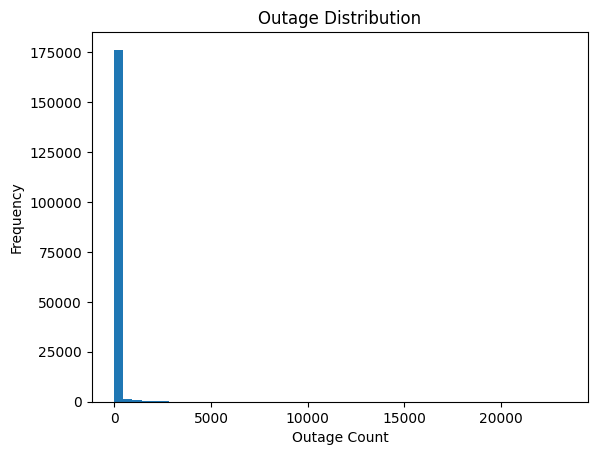

In [12]:
# outcome variable

out = ds_train.out.values.flatten()
print("Basic statistics:")
print(pd.Series(out).describe())

# Proportion of zero values (zero-inflatedg)
zero_ratio = np.mean(out == 0)
print(f"Zero ratio: {zero_ratio:.4f}")

# Plot distribution
plt.figure()
plt.hist(out, bins=50)
plt.title("Outage Distribution")
plt.xlabel("Outage Count")
plt.ylabel("Frequency")
plt.show()



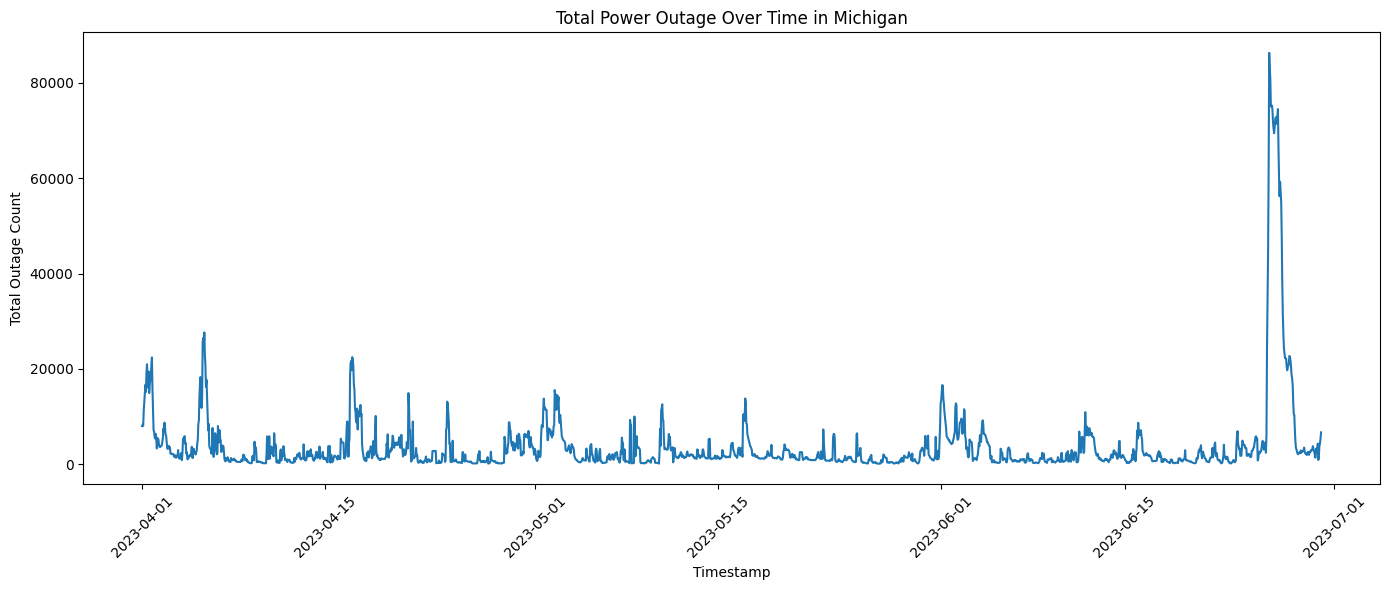

Top 5 Counties: ['26081' '26161' '26099' '26163' '26125']


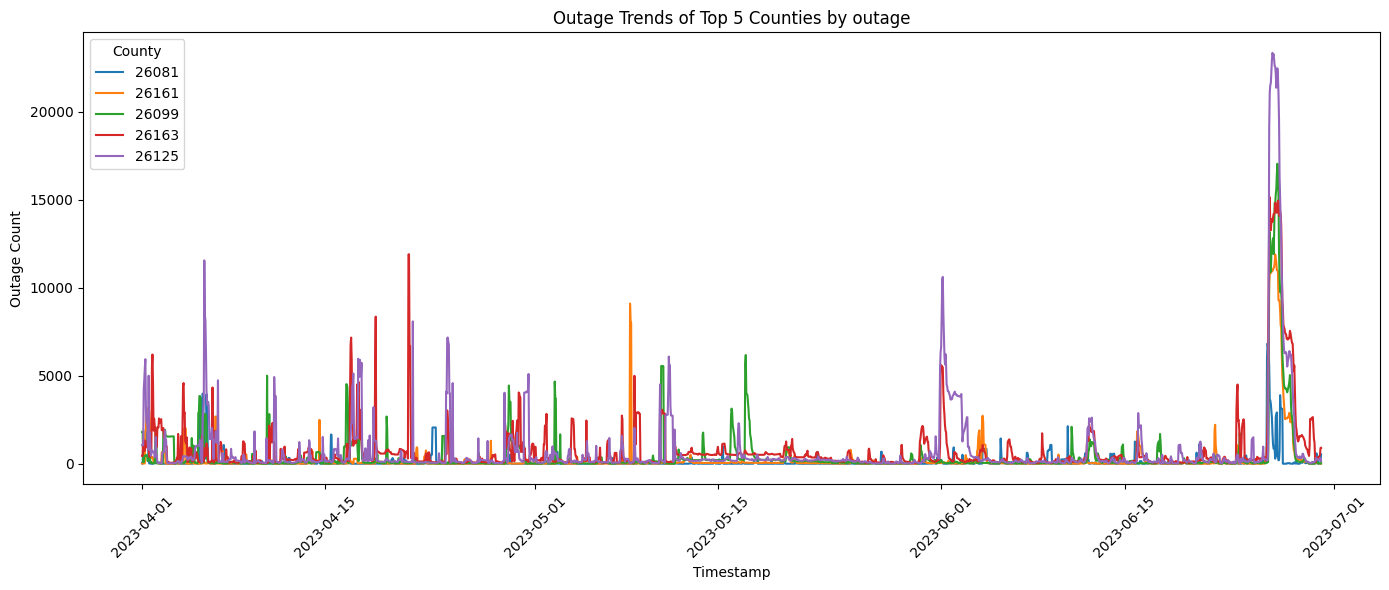

In [13]:
import matplotlib.pyplot as plt

# =========================
# Method 1:
# Statewide Total Outage Over Time
# =========================

# all county sum
statewide_outage = ds_train["out"].sum(dim="location")

plt.figure(figsize=(14, 6))
plt.plot(
    ds_train["timestamp"].values,
    statewide_outage.values
)

plt.title("Total Power Outage Over Time in Michigan")
plt.xlabel("Timestamp")
plt.ylabel("Total Outage Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================
# Method 2:
# Top 5 Counties Outage Over Time
# =========================


total_outage_by_county = ds_train["out"].sum(dim="timestamp")

top5_idx = total_outage_by_county.argsort()[-5:].values

top5_counties = ds_train["location"].values[top5_idx]

print("Top 5 Counties:", top5_counties)


plt.figure(figsize=(14, 6))

for county in top5_counties:
    county_outage = ds_train["out"].sel(location=county)

    plt.plot(
        ds_train["timestamp"].values,
        county_outage.values,
        label=str(county)
    )

plt.title("Outage Trends of Top 5 Counties by outage")
plt.xlabel("Timestamp")
plt.ylabel("Outage Count")
plt.legend(title="County")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

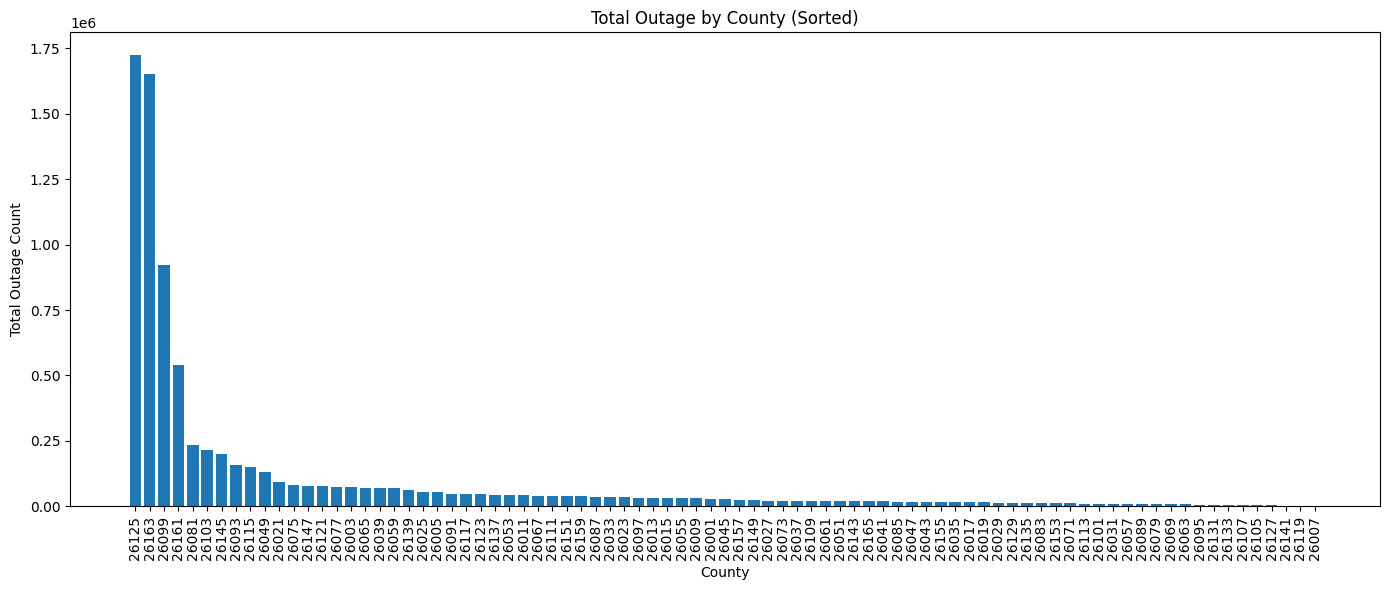

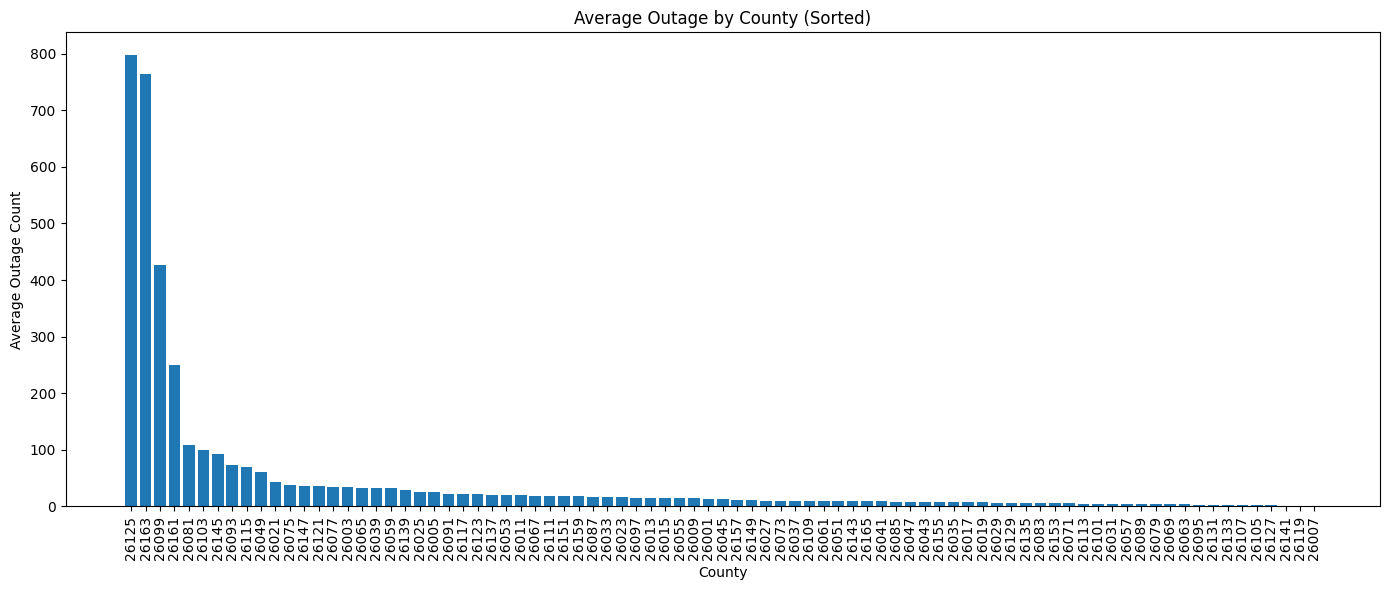

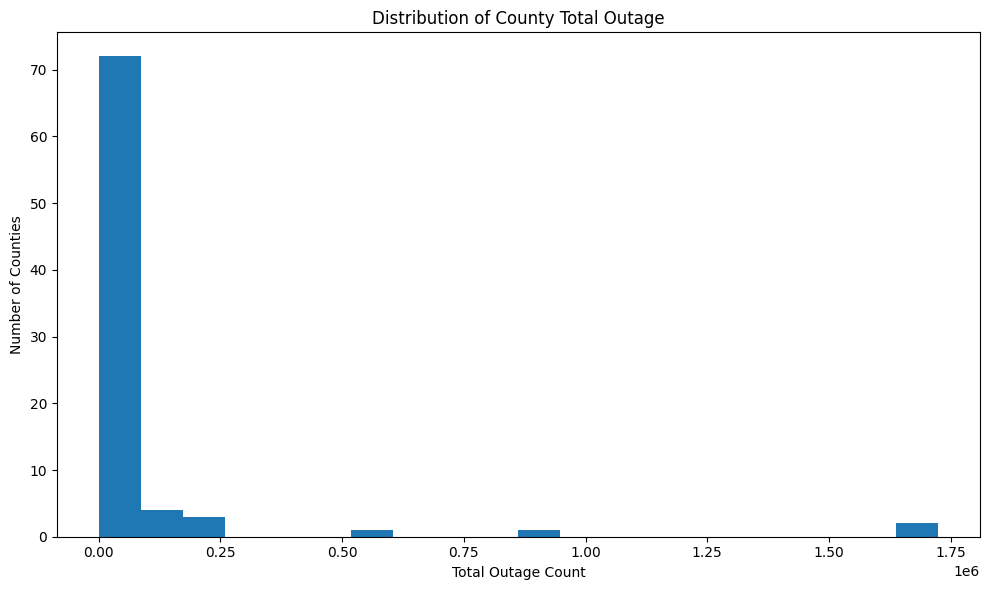

In [15]:
# LOCATION-LEVEL ANALYSIS

# =========================
# EDA 1:
# Total Outage by County (Sorted)
# =========================

total_outage_by_county = ds_train["out"].sum(dim="timestamp")

# county FIPS code
counties = ds_train["location"].values

# sort by total outage (from high to low)
sorted_idx = np.argsort(total_outage_by_county.values)[::-1]

sorted_counties = counties[sorted_idx]
sorted_total_outage = total_outage_by_county.values[sorted_idx]

plt.figure(figsize=(14, 6))
plt.bar(
    sorted_counties.astype(str),
    sorted_total_outage
)

plt.title("Total Outage by County (Sorted)")
plt.xlabel("County")
plt.ylabel("Total Outage Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# =========================
# EDA 2:
# Average Outage by County (Sorted)
# =========================

avg_outage_by_county = ds_train["out"].mean(dim="timestamp")

# sort by average outage (from high to low)
sorted_idx_avg = np.argsort(avg_outage_by_county.values)[::-1]

sorted_counties_avg = counties[sorted_idx_avg]
sorted_avg_outage = avg_outage_by_county.values[sorted_idx_avg]

plt.figure(figsize=(14, 6))
plt.bar(
    sorted_counties_avg.astype(str),
    sorted_avg_outage
)

plt.title("Average Outage by County (Sorted)")
plt.xlabel("County")
plt.ylabel("Average Outage Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# =========================
# EDA 3:
# Histogram of County Total Outage
# =========================

plt.figure(figsize=(10, 6))
plt.hist(
    total_outage_by_county.values,
    bins=20
)

plt.title("Distribution of County Total Outage")
plt.xlabel("Total Outage Count")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

In [16]:
# WEATHER FEATURE ANALYSIS

# Convert to numpy
weather_np = weather_filled.values

# standardize
mean = np.nanmean(weather_np, axis=1, keepdims=True)
std = np.nanstd(weather_np, axis=1, keepdims=True)

weather_std = (weather_np - mean) / (std + 1e-6)

# Compute feature volatility (standard deviation across location and time)
feature_volatility = np.nanstd(weather_std, axis=(0, 1))

# This code standardizes the weather features and identifies
#the most volatile ones by computing their standard deviation
#across all locations and timestamps.
top_idx = np.argsort(feature_volatility)[-10:]
top_features = [weather_features[i] for i in top_idx]

print("Top volatile weather features:")
print(top_features)

Top volatile weather features:
['gh_3', 'gh_4', 'sp', 'mslma', 'pres_1', 'pres_2', 'plpl', 'vis', 'pres', 'pcdb']


In [17]:

# CHECK CONSTANT / ALL-ZERO FEATURES & All-zero samples

weather_flat = weather_filled.values.reshape(-1, weather_filled.shape[-1])
print(weather_flat.shape)

#checks whether each feature consists entirely of zeros across all samples
all_zero_mask = np.all(weather_flat == 0, axis=0)
zero_features = [weather_features[i] for i in range(len(weather_features)) if all_zero_mask[i]]

print(f"Number of all-zero features: {len(zero_features)}")
print("All-zero features:")
print(zero_features)
# can delete these features before training models ?

all_zero_sample_mask = np.all(weather_flat == 0, axis=1)
num_all_zero_samples = np.sum(all_zero_sample_mask)

print(f"Number of all-zero samples: {num_all_zero_samples}")
print(f"Ratio: {num_all_zero_samples / len(weather_flat):.4f}")


(179363, 109)
Number of all-zero features: 17
All-zero features:
['aod', 'bgrun', 'cfrzr', 'cicep', 'crain', 'csnow', 'hail_2', 'ltng', 'prate', 'sdwe_1', 'siconc', 'ssrun', 'tcoli', 'tcolw', 'tp', 'unknown_7', 'unknown_9']
Number of all-zero samples: 166
Ratio: 0.0009


Top correlated feature pairs:
SBT114  SBT124    0.995986
SBT124  SBT114    0.995986
t       pt        0.978391
pt      t         0.978391
r       r_1       0.976330
r_1     r         0.976330
gh_7    gh_6      0.975932
gh_6    gh_7      0.975932
sdwe    sde       0.975533
sde     sdwe      0.975533
dtype: float64


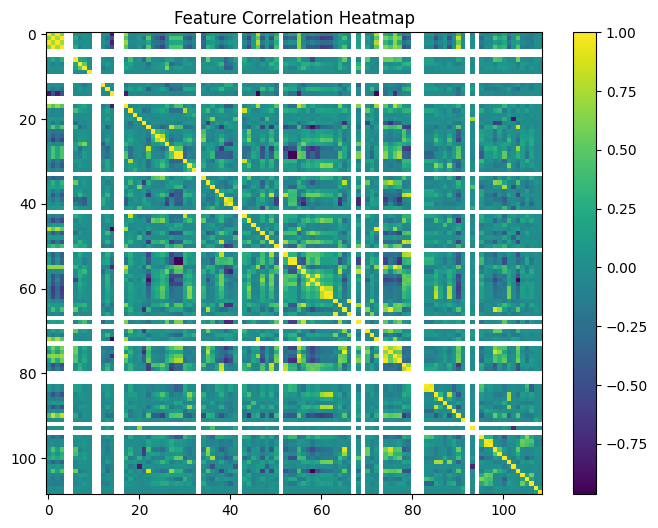

In [18]:

# feature correlation

df_weather = pd.DataFrame(weather_flat, columns=weather_features)

# Compute correlation matrix
corr_matrix = df_weather.corr()

# Show top correlated pairs
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)

# Remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 0.999]

print("Top correlated feature pairs:")
print(corr_pairs.head(10))

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
# FEATURE vs TARGET CORRELATION


out_flat = ds_train.out.values.flatten()
df_weather["out"] = out_flat

# Compute correlation with target
target_corr = df_weather.corr()["out"].drop("out")

# Sort
target_corr_sorted = target_corr.sort_values(ascending=False)

print("Top positively correlated features:")
print(target_corr_sorted.head(10))

print("\nTop negatively correlated features:")
print(target_corr_sorted.tail(10))

Top positively correlated features:
cape         0.119191
pwat         0.089700
sh2          0.083554
gh_4         0.081504
cape_1       0.073289
sdlwrf       0.068874
unknown_3    0.061608
refc         0.059532
lcc          0.055376
hail         0.054625
Name: out, dtype: float64

Top negatively correlated features:
ltng        NaN
prate       NaN
sdwe_1      NaN
siconc      NaN
ssrun       NaN
tcoli       NaN
tcolw       NaN
tp          NaN
unknown_7   NaN
unknown_9   NaN
Name: out, dtype: float64


## 4. Data Preparation

In [20]:
ds_train_clean = xr.Dataset(
    {
        "weather": weather_filled,           # cleaned weather
        "tracked": ds_train.tracked,         # original
        "out": ds_train.out                  # original
    },
    coords={
        "location": ds_train.location,
        "timestamp": ds_train.timestamp,
        "feature": ds_train.feature
    }
)

print(ds_train_clean)

<xarray.Dataset> Size: 159MB
Dimensions:    (location: 83, feature: 109, timestamp: 2161)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
    state      (location) <U2 664B ...
Data variables:
    weather    (location, timestamp, feature) float64 156MB 221.5 ... 0.0244
    tracked    (location, timestamp) float64 1MB 1.259e+04 ... 2.046e+04
    out        (location, timestamp) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0


In [21]:
# train-valid split based on timestamp
T = ds_train_clean.dims["timestamp"]

# Split index
split_idx = int((1 - VALIDATION_SPLIT) * T)

print(f"Total timestamps: {T}")
print(f"Split index: {split_idx}")

# Split timestamps
training_timestamps = ds_train_clean.timestamp[:split_idx]
val_timestamps = ds_train_clean.timestamp[split_idx:]

# Create train and validation datasets
train_data = ds_train_clean.sel(timestamp=training_timestamps)
val_data = ds_train_clean.sel(timestamp=val_timestamps)

print("\nTrain shape:", train_data.weather.shape)
print("Validation shape:", val_data.weather.shape)

print(train_data.timestamp)
print(val_data.timestamp)

Total timestamps: 2161
Split index: 1728

Train shape: (83, 1728, 109)
Validation shape: (83, 433, 109)
<xarray.DataArray 'timestamp' (timestamp: 1728)> Size: 14kB
array(['2023-04-01T00:00:00.000000000', '2023-04-01T01:00:00.000000000',
       '2023-04-01T02:00:00.000000000', ..., '2023-06-11T21:00:00.000000000',
       '2023-06-11T22:00:00.000000000', '2023-06-11T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 14kB 2023-04-01 ... 2023-06-11T23:0...
<xarray.DataArray 'timestamp' (timestamp: 433)> Size: 3kB
array(['2023-06-12T00:00:00.000000000', '2023-06-12T01:00:00.000000000',
       '2023-06-12T02:00:00.000000000', ..., '2023-06-29T22:00:00.000000000',
       '2023-06-29T23:00:00.000000000', '2023-06-30T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 3kB 2023-06-12 ... 2023-06-30


use "train_data" and "val_data" for advanced model training

## Align val dataset with demo!

In [22]:
# Prepare ground truth for last 24 and 48 hours to align with test set
val_truth_24h = val_data.out.transpose("timestamp", "location").isel(timestamp=slice(0, 24)).values.astype(float)
val_truth_48h = val_data.out.transpose("timestamp", "location").isel(timestamp=slice(0, 48)).values.astype(float)

print(f"\Validation set shapes:")
print(f"  24h: {val_truth_24h.shape}")
print(f"  48h: {val_truth_48h.shape}")

\Validation set shapes:
  24h: (24, 83)
  48h: (48, 83)


In [23]:
val_timestamps = pd.to_datetime(val_data.timestamp.values)
val_timestamps_24h = val_timestamps[:24]
val_timestamps_48h = val_timestamps[:48]

print(val_timestamps_24h)
print(val_timestamps_48h)

DatetimeIndex(['2023-06-12 00:00:00', '2023-06-12 01:00:00',
               '2023-06-12 02:00:00', '2023-06-12 03:00:00',
               '2023-06-12 04:00:00', '2023-06-12 05:00:00',
               '2023-06-12 06:00:00', '2023-06-12 07:00:00',
               '2023-06-12 08:00:00', '2023-06-12 09:00:00',
               '2023-06-12 10:00:00', '2023-06-12 11:00:00',
               '2023-06-12 12:00:00', '2023-06-12 13:00:00',
               '2023-06-12 14:00:00', '2023-06-12 15:00:00',
               '2023-06-12 16:00:00', '2023-06-12 17:00:00',
               '2023-06-12 18:00:00', '2023-06-12 19:00:00',
               '2023-06-12 20:00:00', '2023-06-12 21:00:00',
               '2023-06-12 22:00:00', '2023-06-12 23:00:00'],
              dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2023-06-12 00:00:00', '2023-06-12 01:00:00',
               '2023-06-12 02:00:00', '2023-06-12 03:00:00',
               '2023-06-12 04:00:00', '2023-06-12 05:00:00',
               '2023-06-12 06:00:00

## 5. Baseline Model

#### 5.0 All zero

In [24]:
# -------------------------------
# All Zero Baseline Model
# -------------------------------

def all_zero_baseline(truth_array):
    """
    Create all-zero baseline prediction

    Input:
        truth_array: numpy array of ground truth
                     shape example: (24, num_locations)

    Output:
        pred_array: same shape as truth_array, filled with 0
    """
    pred_array = np.zeros_like(truth_array, dtype=float)
    return pred_array


# -------------------------------
# RMSE Calculation Function
# -------------------------------

def calculate_rmse(y_true, y_pred):
    """
    Calculate RMSE based on assignment definition:
    1. Compute RMSE for each county (location)
    2. Average RMSE across all counties

    Input:
        y_true: ground truth, shape = (T, N)
        y_pred: prediction, shape = (T, N)

        T = forecast horizon (24 or 48)
        N = number of counties

    Output:
        avg_rmse: averaged RMSE across all counties
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # check shape
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shape mismatch: y_true {y_true.shape} vs y_pred {y_pred.shape}")

    # RMSE for each county
    county_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

    # Final score = average RMSE across all counties
    avg_rmse = np.mean(county_rmse)

    return avg_rmse

In [25]:
all_zero_pred_24h = all_zero_baseline(val_truth_24h)
rmse_all_zero_24h = calculate_rmse(val_truth_24h, all_zero_pred_24h)

print(f"All Zero Baseline RMSE (24h): {rmse_all_zero_24h:.4f}")

All Zero Baseline RMSE (24h): 100.3053


In [26]:
all_zero_pred_48h = all_zero_baseline(val_truth_48h)
rmse_all_zero_48h = calculate_rmse(val_truth_48h, all_zero_pred_48h)

print(f"All Zero Baseline RMSE (48h): {rmse_all_zero_48h:.4f}")

All Zero Baseline RMSE (48h): 75.3561
